## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              f1_score, roc_auc_score, RocCurveDisplay)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42


In [2]:
DATA_PATH = "Country-data.csv"  # update path if needed

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 2. Data Preprocessing




In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [4]:
print("Missing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)


Missing values:
 country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate rows: 0


In [5]:
feature_cols = ['child_mort', 'exports', 'health', 'imports', 'income',
                'inflation', 'life_expec', 'total_fer', 'gdpp']

def iqr_outlier_report(frame, cols):
    report = {}
    for c in cols:
        q1, q3 = frame[c].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
        n_out = ((frame[c] < lower) | (frame[c] > upper)).sum()
        report[c] = n_out
    return pd.Series(report, name='outlier_count')

iqr_outlier_report(df, feature_cols)


,outlier_count
child_mort,4
exports,5
health,2
imports,4
income,8
inflation,5
life_expec,3
total_fer,1
gdpp,25


In [6]:
df['income_log'] = np.log1p(df['income'])
df['gdpp_log'] = np.log1p(df['gdpp'])

df[feature_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


## 3. Exploratory Data Analysis (EDA)


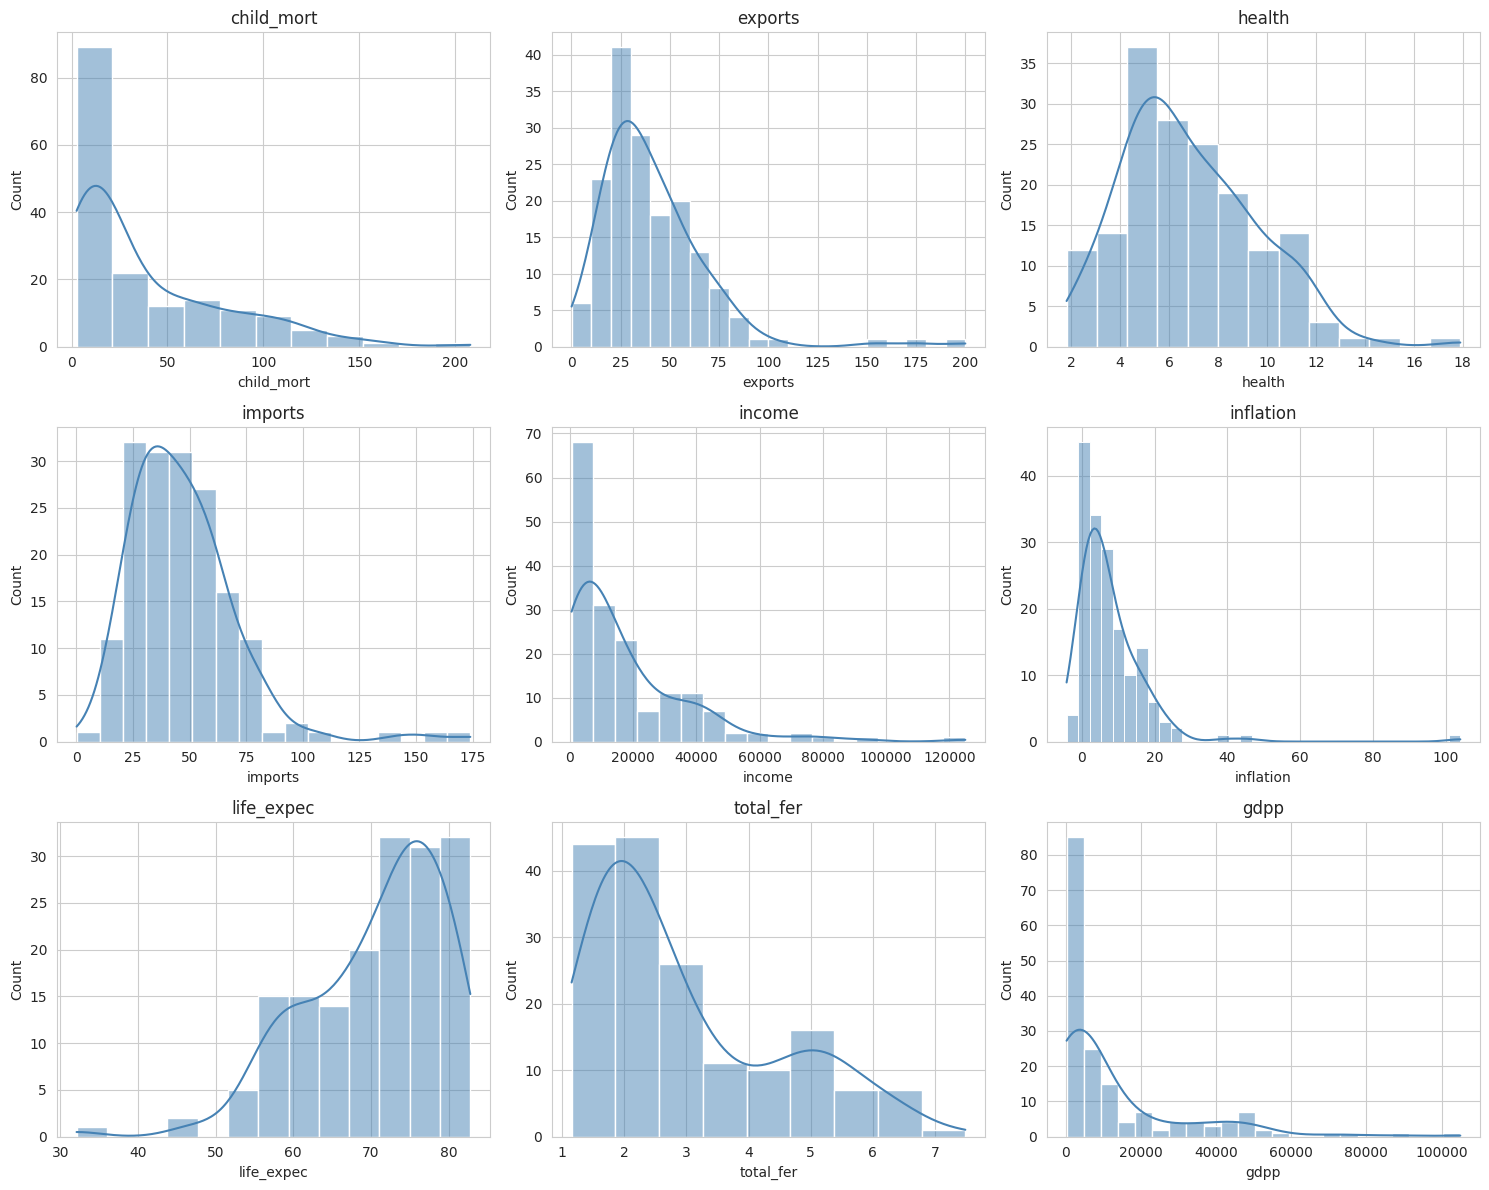

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flatten(), feature_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()


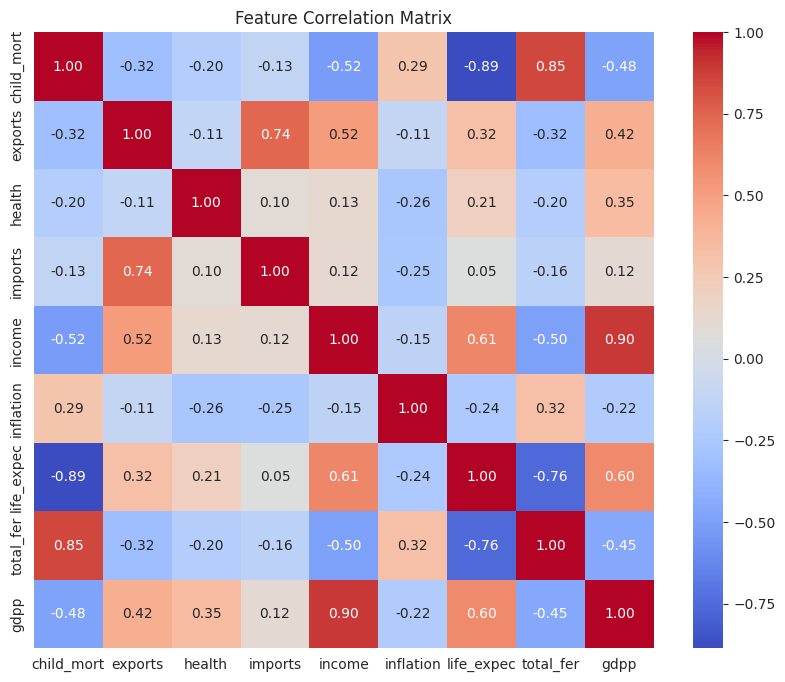

In [8]:
plt.figure(figsize=(10,8))
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()


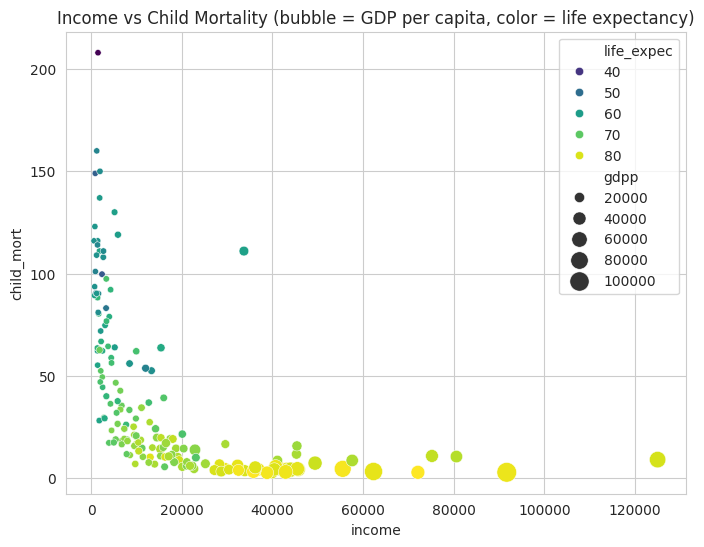

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='income', y='child_mort', size='gdpp', hue='life_expec',
                 palette='viridis', sizes=(20,200))
plt.title('Income vs Child Mortality (bubble = GDP per capita, color = life expectancy)')
plt.show()


In [10]:
top_poor = df.nsmallest(10, 'gdpp')[['country','gdpp','income','child_mort','life_expec']]
top_rich = df.nlargest(10, 'gdpp')[['country','gdpp','income','child_mort','life_expec']]
print("Lowest GDP per capita:\n", top_poor.to_string(index=False))
print("\nHighest GDP per capita:\n", top_rich.to_string(index=False))


Lowest GDP per capita:
                  country  gdpp  income  child_mort  life_expec
                 Burundi   231     764        93.6        57.7
                 Liberia   327     700        89.3        60.8
        Congo, Dem. Rep.   334     609       116.0        57.5
                   Niger   348     814       123.0        58.8
            Sierra Leone   399    1220       160.0        55.0
              Madagascar   413    1390        62.2        60.8
              Mozambique   419     918       101.0        54.5
Central African Republic   446     888       149.0        47.5
                  Malawi   459    1030        90.5        53.1
                 Eritrea   482    1420        55.2        61.7

Highest GDP per capita:
       country   gdpp  income  child_mort  life_expec
   Luxembourg 105000   91700         2.8        81.3
       Norway  87800   62300         3.2        81.0
  Switzerland  74600   55500         4.5        82.2
        Qatar  70300  125000         9.0     

## 4. Feature Engineering




In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_components = pca.fit_transform(X_scaled)
df['pca1'] = pca_components[:, 0]
df['pca2'] = pca_components[:, 1]
print("Explained variance ratio:", pca.explained_variance_ratio_, "sum:", pca.explained_variance_ratio_.sum())


Explained variance ratio: [0.4595174  0.17181626] sum: 0.6313336543771411


## 5. Clustering — Customer/Entity Segmentation

### 5a. K-Means (with Elbow Method + Silhouette Score to choose k)


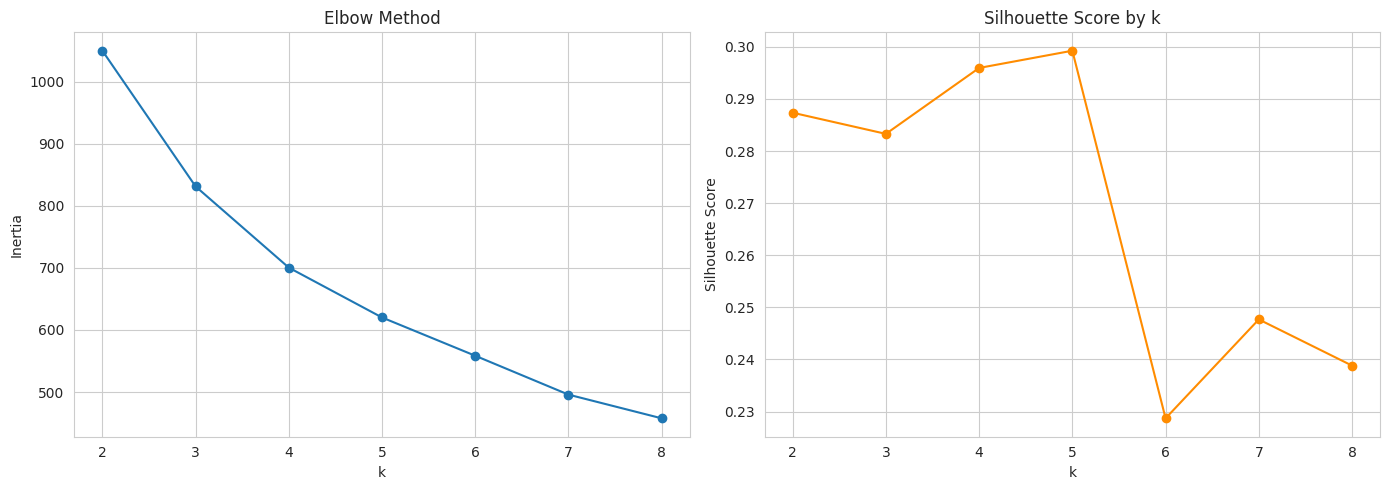

Selected k (favoring k=3 for interpretable Needs-Help/Developing/Developed segments
when its silhouette/cluster-size profile is reasonable): 3


In [12]:
inertia = []
sil_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(list(k_range), inertia, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), sil_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

candidate_ks = []
for k, sil in zip(k_range, sil_scores):
    km_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    min_cluster_size = pd.Series(km_tmp.labels_).value_counts().min()
    if min_cluster_size >= 10:
        candidate_ks.append((k, sil))

best_k = 3 if any(k == 3 for k, _ in candidate_ks) else (max(candidate_ks, key=lambda x: x[1])[0] if candidate_ks else 3)
print("Selected k (favoring k=3 for interpretable Needs-Help/Developing/Developed segments")
print("when its silhouette/cluster-size profile is reasonable):", best_k)


In [13]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster sizes:\n", df['kmeans_cluster'].value_counts().sort_index())
print("\nSilhouette score:", silhouette_score(X_scaled, df['kmeans_cluster']))
print("Davies-Bouldin score:", davies_bouldin_score(X_scaled, df['kmeans_cluster']))


Cluster sizes:
 kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64

Silhouette score: 0.28329575683463126
Davies-Bouldin score: 1.2769056099698288


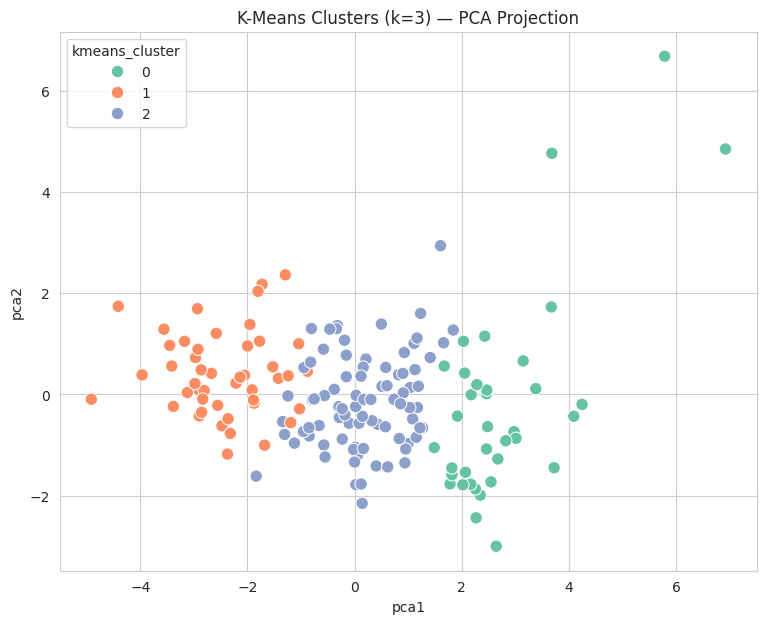

In [14]:
plt.figure(figsize=(9,7))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='kmeans_cluster', palette='Set2', s=80)
plt.title(f'K-Means Clusters (k={best_k}) — PCA Projection')
plt.show()


In [15]:
cluster_profile = df.groupby('kmeans_cluster')[feature_cols].mean().round(1)
cluster_profile['n_countries'] = df['kmeans_cluster'].value_counts().sort_index()
cluster_profile


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,n_countries
kmeans_cluster,,,,,,,,,,
0,5.0,58.7,8.8,51.5,45672.2,2.7,80.1,1.8,42494.4,36
1,93.0,29.2,6.4,42.3,3942.4,12.0,59.2,5.0,1922.4,47
2,21.9,40.2,6.2,47.5,12305.6,7.6,72.8,2.3,6486.5,84


### 5b. DBSCAN (density-based clustering, finds outliers/noise automatically)


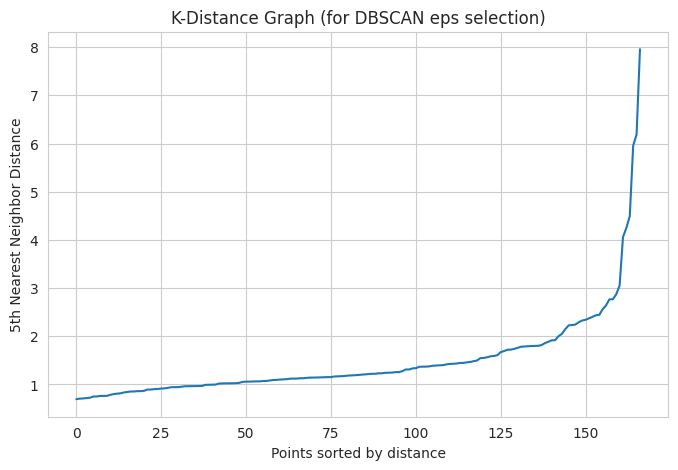

In [16]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title('K-Distance Graph (for DBSCAN eps selection)')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.show()


In [17]:
dbscan = DBSCAN(eps=1.0, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
n_noise = (df['dbscan_cluster'] == -1).sum()
print(f"DBSCAN found {n_clusters_db} clusters and {n_noise} noise points")
print(df['dbscan_cluster'].value_counts().sort_index())


DBSCAN found 3 clusters and 94 noise points
dbscan_cluster
-1    94
 0    52
 1    16
 2     5
Name: count, dtype: int64


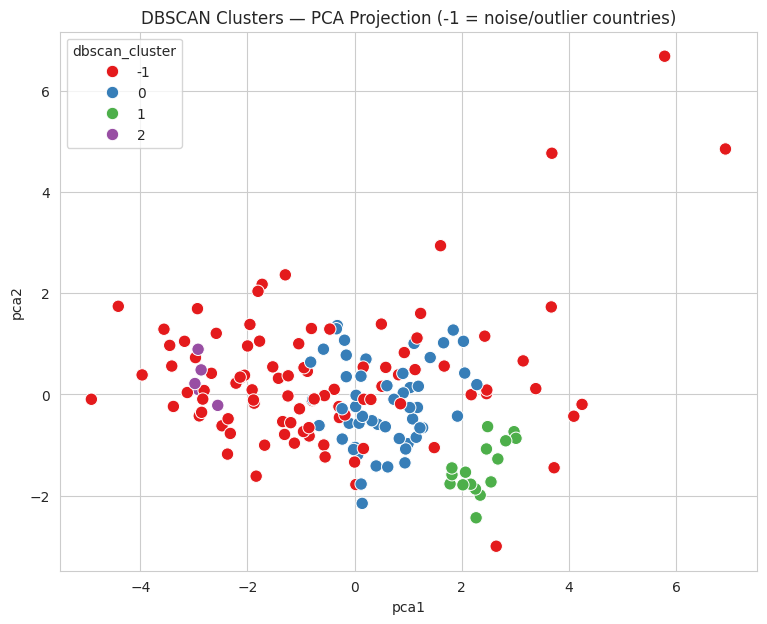

In [18]:
plt.figure(figsize=(9,7))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='dbscan_cluster', palette='Set1', s=80)
plt.title('DBSCAN Clusters — PCA Projection (-1 = noise/outlier countries)')
plt.show()


In [19]:

df[df['dbscan_cluster'] == -1][['country'] + feature_cols].sort_values('gdpp')


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
26,Burundi,93.6,8.92,11.60,39.2,764,12.300,57.7,6.26,231
88,Liberia,89.3,19.10,11.80,92.6,700,5.470,60.8,5.02,327
37,"Congo, Dem. Rep.",116.0,41.10,7.91,49.6,609,20.800,57.5,6.54,334
112,Niger,123.0,22.20,5.16,49.1,814,2.550,58.8,7.49,348
132,Sierra Leone,160.0,16.80,13.10,34.5,1220,17.200,55.0,5.20,399
...,...,...,...,...,...,...,...,...,...,...
110,Netherlands,4.5,72.00,11.90,63.6,45500,0.848,80.7,1.79,50300
123,Qatar,9.0,62.30,1.81,23.8,125000,6.980,79.5,2.07,70300
145,Switzerland,4.5,64.00,11.50,53.3,55500,0.317,82.2,1.52,74600
114,Norway,3.2,39.70,9.48,28.5,62300,5.950,81.0,1.95,87800


## 6. Translating Clusters into Actionable Segments



In [20]:

score_df = cluster_profile.copy()
composite = (
    -score_df['child_mort'].rank() +
    score_df['income'].rank() +
    score_df['life_expec'].rank() +
    score_df['gdpp'].rank() -
    score_df['inflation'].rank()
)
score_df['composite_rank'] = composite.rank()
ordered_clusters = score_df.sort_values('composite_rank').index.tolist()
print("Clusters ordered from most-need to most-developed:", ordered_clusters)

n_segments = len(ordered_clusters)
if n_segments == 3:
    segment_names = ['Needs Help', 'Developing', 'Developed']
elif n_segments == 2:
    segment_names = ['Needs Help', 'Developed']
else:
    segment_names = [f'Tier {i+1}' for i in range(n_segments)]

cluster_to_segment = {cl: segment_names[i] for i, cl in enumerate(ordered_clusters)}
df['segment'] = df['kmeans_cluster'].map(cluster_to_segment)
df['segment'].value_counts()


Clusters ordered from most-need to most-developed: [1, 2, 0]


,count
segment,
Developing,84
Needs Help,47
Developed,36


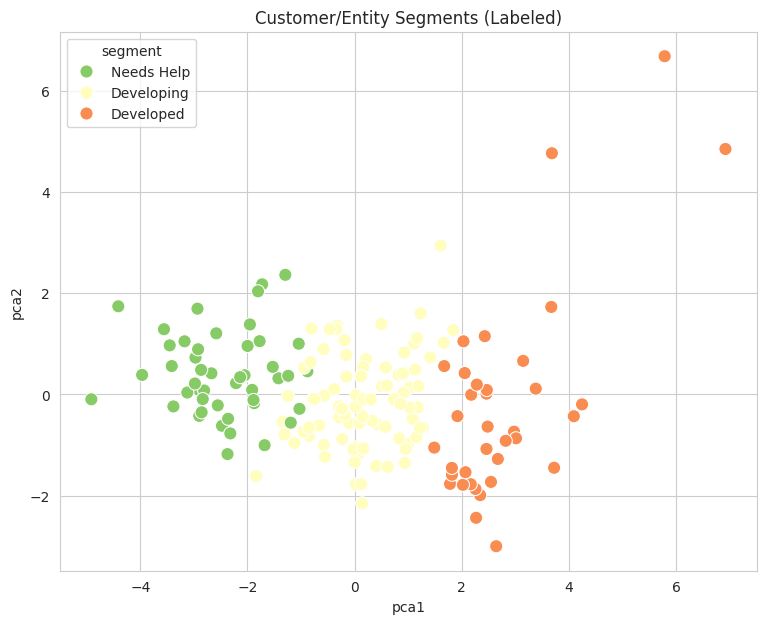

In [21]:
plt.figure(figsize=(9,7))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='segment',
                 palette='RdYlGn_r' if n_segments==3 else 'Set2', s=90)
plt.title('Customer/Entity Segments (Labeled)')
plt.show()


In [22]:
segment_summary = df.groupby('segment')[feature_cols].mean().round(1)
segment_summary


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
segment,,,,,,,,,
Developed,5.0,58.7,8.8,51.5,45672.2,2.7,80.1,1.8,42494.4
Developing,21.9,40.2,6.2,47.5,12305.6,7.6,72.8,2.3,6486.5
Needs Help,93.0,29.2,6.4,42.3,3942.4,12.0,59.2,5.0,1922.4


## 7. Classification — Predicting Segment Membership




In [23]:
X = df[feature_cols]
y = df['segment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(X_train.shape, X_test.shape)
print(y_train.value_counts())


(133, 9) (34, 9)
segment
Developing    67
Needs Help    37
Developed     29
Name: count, dtype: int64


In [24]:
scaler_clf = StandardScaler()
X_train_scaled = scaler_clf.fit_transform(X_train)
X_test_scaled = scaler_clf.transform(X_test)

y_train_xgb = y_train.astype('category').cat.codes
y_test_xgb = y_test.astype('category').cat.codes
label_map = dict(enumerate(y_train.astype('category').cat.categories))
print("Label mapping for XGBoost:", label_map)


Label mapping for XGBoost: {0: 'Developed', 1: 'Developing', 2: 'Needs Help'}


In [25]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=300, random_state=RANDOM_STATE,
                              eval_metric='mlogloss', use_label_encoder=False)
}

results = []
fitted = {}

for name, model in models.items():
    if name == 'XGBoost':
        model.fit(X_train_scaled, y_train_xgb)
        preds = model.predict(X_test_scaled)
        preds_labels = pd.Series(preds).map(label_map)
        acc = accuracy_score(y_test, preds_labels)
        f1 = f1_score(y_test, preds_labels, average='weighted')
    else:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average='weighted')

    results.append({'Model': name, 'Accuracy': acc, 'F1 (weighted)': f1})
    fitted[name] = model

results_df = pd.DataFrame(results).sort_values('F1 (weighted)', ascending=False)
results_df


,Model,Accuracy,F1 (weighted)
0,LogisticRegression,0.970588,0.971123
1,RandomForest,0.941176,0.941383
2,XGBoost,0.941176,0.941383


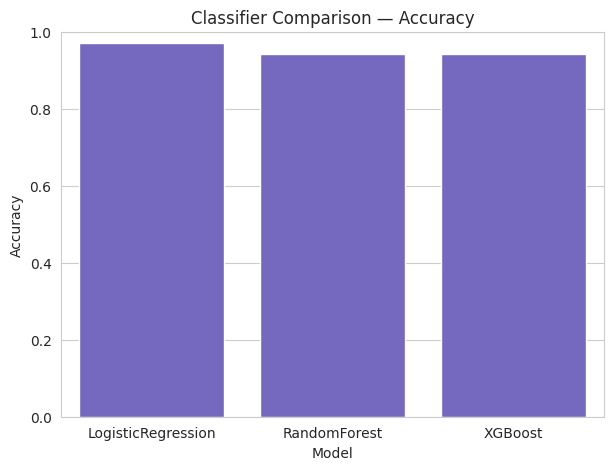

In [26]:
plt.figure(figsize=(7,5))
sns.barplot(data=results_df, x='Model', y='Accuracy', color='slateblue')
plt.title('Classifier Comparison — Accuracy')
plt.ylim(0,1)
plt.show()


Best model: LogisticRegression
              precision    recall  f1-score   support

   Developed       0.88      1.00      0.93         7
  Developing       1.00      0.94      0.97        17
  Needs Help       1.00      1.00      1.00        10

    accuracy                           0.97        34
   macro avg       0.96      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



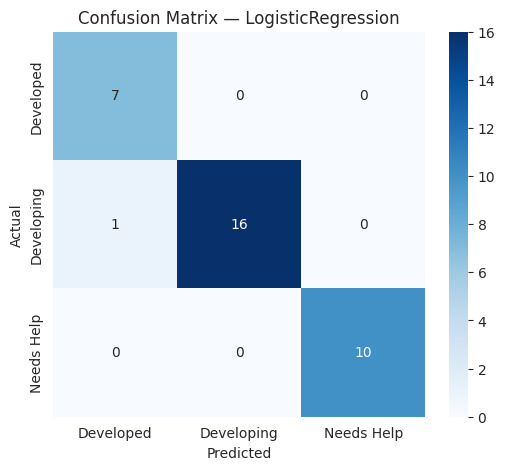

In [27]:
best_name = results_df.iloc[0]['Model']
print("Best model:", best_name)

if best_name == 'XGBoost':
    preds = pd.Series(fitted['XGBoost'].predict(X_test_scaled)).map(label_map)
else:
    preds = fitted[best_name].predict(X_test_scaled)

print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds, labels=sorted(y.unique()))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


## 8. Hyperparameter Tuning (Ensemble Models)



In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE), rf_param_grid,
    cv=cv, scoring='f1_weighted', n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV F1:", rf_grid.best_score_)

Best RF params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best RF CV F1: 0.9699339946747354


In [31]:
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='mlogloss', use_label_encoder=False),
    xgb_param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1
)
xgb_grid.fit(X_train_scaled, y_train_xgb)

print("Best XGB params:", xgb_grid.best_params_)
print("Best XGB CV F1:", xgb_grid.best_score_)


Best XGB params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
Best XGB CV F1: 0.954772160413186


In [32]:
tuned_rf = rf_grid.best_estimator_
tuned_xgb = xgb_grid.best_estimator_

rf_preds = tuned_rf.predict(X_test_scaled)
xgb_preds = pd.Series(tuned_xgb.predict(X_test_scaled)).map(label_map)

final_results = pd.DataFrame([
    {'Model': 'RandomForest (tuned)', 'Accuracy': accuracy_score(y_test, rf_preds),
     'F1 (weighted)': f1_score(y_test, rf_preds, average='weighted')},
    {'Model': 'XGBoost (tuned)', 'Accuracy': accuracy_score(y_test, xgb_preds),
     'F1 (weighted)': f1_score(y_test, xgb_preds, average='weighted')},
])
final_results = pd.concat([results_df, final_results]).sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)
final_results


,Model,Accuracy,F1 (weighted)
0,LogisticRegression,0.970588,0.971123
1,RandomForest,0.941176,0.941383
2,XGBoost,0.941176,0.941383
3,RandomForest (tuned),0.941176,0.941383
4,XGBoost (tuned),0.941176,0.941383


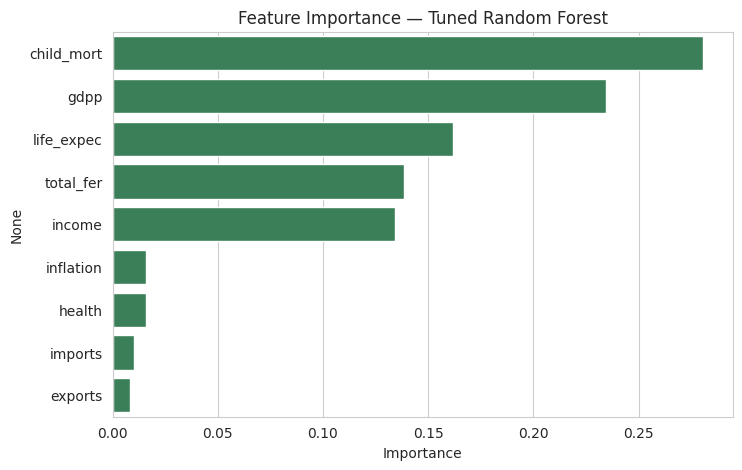

In [33]:
importances = pd.Series(tuned_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, color='seagreen')
plt.title('Feature Importance — Tuned Random Forest')
plt.xlabel('Importance')
plt.show()


## 9. Actionable Insights


In [34]:
segment_action_map = {
    'Needs Help': 'Priority outreach / resource allocation',
    'Developing': 'Monitor & support growth programs',
    'Developed': 'Maintain / partnership opportunities'
}
df['recommended_action'] = df['segment'].map(segment_action_map).fillna('Review individually')

priority_list = df[df['segment'] == segment_names[0]][
    ['country', 'child_mort', 'income', 'gdpp', 'life_expec', 'segment', 'recommended_action']
].sort_values('gdpp').reset_index(drop=True)

print(f"Top entities in the '{segment_names[0]}' segment (highest priority):")
priority_list.head(15)


Top entities in the 'Needs Help' segment (highest priority):


,country,child_mort,income,gdpp,life_expec,segment,recommended_action
0,Burundi,93.6,764,231,57.7,Needs Help,Priority outreach / resource allocation
1,Liberia,89.3,700,327,60.8,Needs Help,Priority outreach / resource allocation
2,"Congo, Dem. Rep.",116.0,609,334,57.5,Needs Help,Priority outreach / resource allocation
3,Niger,123.0,814,348,58.8,Needs Help,Priority outreach / resource allocation
4,Sierra Leone,160.0,1220,399,55.0,Needs Help,Priority outreach / resource allocation
5,Madagascar,62.2,1390,413,60.8,Needs Help,Priority outreach / resource allocation
6,Mozambique,101.0,918,419,54.5,Needs Help,Priority outreach / resource allocation
7,Central African Republic,149.0,888,446,47.5,Needs Help,Priority outreach / resource allocation
8,Malawi,90.5,1030,459,53.1,Needs Help,Priority outreach / resource allocation
9,Eritrea,55.2,1420,482,61.7,Needs Help,Priority outreach / resource allocation


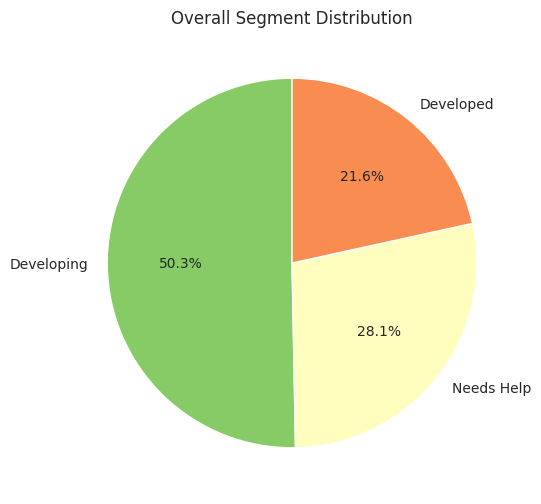

In [35]:
plt.figure(figsize=(10,6))
segment_counts = df['segment'].value_counts()
colors = sns.color_palette('RdYlGn_r', len(segment_counts)) if n_segments==3 else sns.color_palette('Set2', len(segment_counts))
plt.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Overall Segment Distribution')
plt.show()
